In [57]:
# %pip install --upgrade kagglehub pandas

In [58]:
import zipfile
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

# we want to load the kaggle datasets directly from their API, instead of manually downloading
# Hence written this function as it requires more than 1 datasets

def read_datasets_from_kaggle(handle: str, file_name: str):
    if not handle :
        raise ValueError("Dataset handle is mandatory, cannot be empty or None.")
    if not file_name :
        raise ValueError("File name is mandatory, cannot be empty or None.")

    handle = handle.strip()
    file_name = file_name.strip()
    pandas_kwargs = {
        "encoding": "latin-1",
        # "on_bad_lines": "skip",
        "low_memory": False,
    }

    try:
        return kagglehub.dataset_load(
            KaggleDatasetAdapter.PANDAS,
            handle,
            file_name,
            pandas_kwargs=pandas_kwargs,
        )
    except Exception as exc:
        # some of the datasets are named as csv files but are actually ZIP files,
        # so this logic added to handle that case
        temp_file = kagglehub.dataset_download(handle, file_name, force_download=True)

        if zipfile.is_zipfile(temp_file):
            with zipfile.ZipFile(temp_file) as zf:
                names = zf.namelist()
                csv_file_name = next((n for n in names if n.lower().endswith(".csv")), names[0])
                with zf.open(csv_file_name) as f:
                    return pd.read_csv(f, **pandas_kwargs)

        return pd.read_csv(temp_file, **pandas_kwargs)

In [59]:
# This function is used to explore the dataset and get the basic information about the dataset 
# such as number of records, columns, data types, nulls, unique values and summary of the dataset
def explore_my_dataset(df):    

    print("___________________________________________________")
    print("Total records in the dataset :", len(df))
    print("___________________________________________________")

    # Want to validate the columns and the data types of those columns
    print("Column names and data types:\n", df.dtypes)
    print("___________________________________________________")

    # Validate the nulls
    print("Nulls in each column:\n", df.isnull().sum())
    print("___________________________________________________")

    # Validate the unique records in the given dataset
    print("Unique values in each column:\n", df.nunique())
    print("___________________________________________________")

    # Summary of the dataset
    print("Summary :\n", df.describe(include='all'))
    print("___________________________________________________")

In [60]:

# Pull kiva_loans dataset from Kaggle and load it into a pandas DataFrame
handle = "kiva/data-science-for-good-kiva-crowdfunding"
file_name = "kiva_loans.csv"
df_kiva_loans = read_datasets_from_kaggle(handle, file_name)

#print sample data
print("Sample data from -", file_name)
display(df_kiva_loans)

Sample data from - kiva_loans.csv


,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,partner_id,posted_time,disbursed_time,funded_time,term_in_months,lender_count,tags,borrower_genders,repayment_interval,date
0,653051,300.0,300.0,Fruits & Vegetables,Food,"To buy seasonal, fresh fruits to sell.",PK,Pakistan,Lahore,PKR,247.0,2014-01-01 06:12:39+00:00,2013-12-17 08:00:00+00:00,2014-01-02 10:06:32+00:00,12.0,12,NaN,female,irregular,2014-01-01
1,653053,575.0,575.0,Rickshaw,Transportation,to repair and maintain the auto rickshaw used ...,PK,Pakistan,Lahore,PKR,247.0,2014-01-01 06:51:08+00:00,2013-12-17 08:00:00+00:00,2014-01-02 09:17:23+00:00,11.0,14,NaN,"female, female",irregular,2014-01-01
2,653068,150.0,150.0,Transportation,Transportation,To repair their old cycle-van and buy another ...,IN,India,Maynaguri,INR,334.0,2014-01-01 09:58:07+00:00,2013-12-17 08:00:00+00:00,2014-01-01 16:01:36+00:00,43.0,6,"user_favorite, user_favorite",female,bullet,2014-01-01
3,653063,200.0,200.0,Embroidery,Arts,to purchase an embroidery machine and a variet...,PK,Pakistan,Lahore,PKR,247.0,2014-01-01 08:03:11+00:00,2013-12-24 08:00:00+00:00,2014-01-01 13:00:00+00:00,11.0,8,NaN,female,irregular,2014-01-01
4,653084,400.0,400.0,Milk Sales,Food,to purchase one buffalo.,PK,Pakistan,Abdul Hakeem,PKR,245.0,2014-01-01 11:53:19+00:00,2013-12-17 08:00:00+00:00,2014-01-01 19:18:51+00:00,14.0,16,NaN,female,monthly,2014-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
671200,1340323,0.0,25.0,Livestock,Agriculture,"[True, u'para compara: cemento, arenya y ladri...",PY,Paraguay,ConcepciÃ³n,USD,58.0,2017-07-25 16:55:34+00:00,2017-07-25 07:00:00+00:00,NaN,13.0,0,NaN,female,monthly,2017-07-25
671201,1340316,25.0,25.0,Livestock,Agriculture,"[True, u'to start a turducken farm.'] - this l...",KE,Kenya,NaN,KES,138.0,2017-07-25 06:14:08+00:00,2017-07-24 07:00:00+00:00,2017-07-26 02:09:43+00:00,13.0,1,NaN,female,monthly,2017-07-25
671202,1340334,0.0,25.0,Games,Entertainment,NaN,KE,Kenya,NaN,KES,138.0,2017-07-26 00:02:07+00:00,2017-07-25 07:00:00+00:00,NaN,13.0,0,NaN,NaN,monthly,2017-07-26
671203,1340338,0.0,25.0,Livestock,Agriculture,"[True, u'to start a turducken farm.'] - this l...",KE,Kenya,NaN,KES,138.0,2017-07-26 06:12:55+00:00,2017-07-25 07:00:00+00:00,NaN,13.0,0,NaN,female,monthly,2017-07-26


In [61]:
#Let's do the data exploration for this dataset

#Basic validation of the dataset
explore_my_dataset(df_kiva_loans)

#additonal validations such as funding, gender categorical data, outliers etc 
invalid_amounts = df_kiva_loans[
    (df_kiva_loans["loan_amount"] <= 0) |
    (df_kiva_loans["funded_amount"] < 0) |
    (df_kiva_loans["funded_amount"] > df_kiva_loans["loan_amount"])
]

if invalid_amounts.empty:
    print(" Loan and funded amounts are valid in this dataset")
else:
    print(f" Found {len(invalid_amounts)} invalid amount records.")
    display(invalid_amounts[["id", "loan_amount", "funded_amount"]].head())

# outlier checks
for column in ["loan_amount", "term_in_months", "lender_count"]:
    mean = df_kiva_loans[column].mean()
    std = df_kiva_loans[column].std()

    outliers = df_kiva_loans[
        (df_kiva_loans[column] < mean - 3 * std) |
        (df_kiva_loans[column] > mean + 3 * std)
    ]

    if outliers.empty:
        print(f"PASS: No major outliers in {column}.")
    else:
        print(f"WARNING: {len(outliers)} possible outliers found in {column}.")

___________________________________________________
Total records in the dataset : 671205
___________________________________________________
Column names and data types:
 id                      int64
funded_amount         float64
loan_amount           float64
activity               object
sector                 object
use                    object
country_code           object
country                object
region                 object
currency               object
partner_id            float64
posted_time            object
disbursed_time         object
funded_time            object
term_in_months        float64
lender_count            int64
tags                   object
borrower_genders       object
repayment_interval     object
date                   object
dtype: object
___________________________________________________
Nulls in each column:
 id                         0
funded_amount              0
loan_amount                0
activity                   0
sector                 

,id,loan_amount,funded_amount
277188,924149,400.0,425.0
338159,985199,3000.0,3400.0


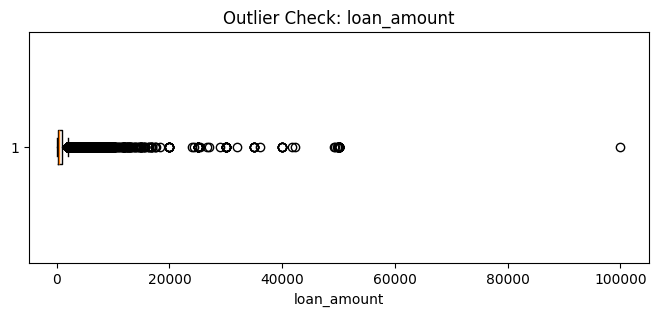

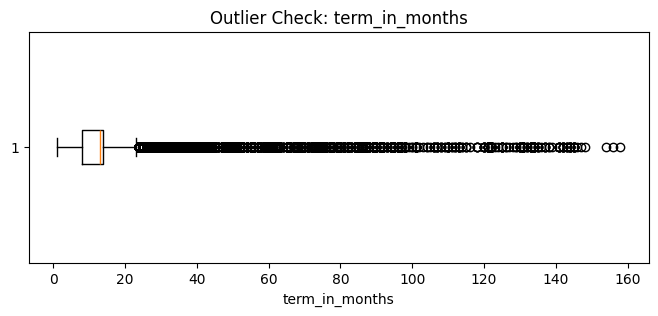

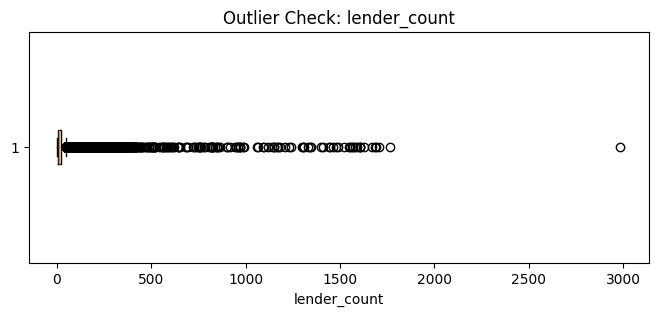

In [62]:
# want to see the boxplots for the columns to visually check for outliers
import matplotlib.pyplot as plt

columns = ["loan_amount", "term_in_months", "lender_count"]

for column in columns:
    plt.figure(figsize=(8, 3))
    plt.boxplot(df_kiva_loans[column].dropna(), vert=False)
    plt.title(f"Outlier Check: {column}")
    plt.xlabel(column)
    plt.show()

In [63]:

# Pull loan_themes_by_region dataset from Kaggle and load it into a pandas DataFrame
handle = "kiva/data-science-for-good-kiva-crowdfunding"
file_name = "loan_themes_by_region.csv"
df_loan_themes_by_region = read_datasets_from_kaggle(handle, file_name)

#print sample data 
print("Sample data from -", file_name)
display(df_loan_themes_by_region)

100%|██████████████████████████████████████████████████████████████████████████████████████| 528k/528k [00:00<00:00, 2.14MB/s]

Sample data from - loan_themes_by_region.csv


,Partner ID,Field Partner Name,sector,Loan Theme ID,Loan Theme Type,country,forkiva,region,geocode_old,ISO,...,amount,LocationName,geocode,names,geo,lat,lon,mpi_region,mpi_geo,rural_pct
0,9,KREDIT Microfinance Institution,General Financial Inclusion,a1050000000slfi,Higher Education,Cambodia,No,Banteay Meanchey,"(13.75, 103.0)",KHM,...,450,"Banteay Meanchey, Cambodia","[(13.6672596, 102.8975098)]",Banteay Meanchey Province; Cambodia,"(13.6672596, 102.8975098)",13.667260,102.897510,"Banteay Mean Chey, Cambodia","(13.6672596, 102.8975098)",90.0
1,9,KREDIT Microfinance Institution,General Financial Inclusion,a10500000068jPe,Vulnerable Populations,Cambodia,No,Battambang Province,NaN,KHM,...,20275,"Battambang Province, Cambodia","[(13.0286971, 102.989615)]",Battambang Province; Cambodia,"(13.0286971, 102.989615)",13.028697,102.989615,"Banteay Mean Chey, Cambodia","(13.6672596, 102.8975098)",90.0
2,9,KREDIT Microfinance Institution,General Financial Inclusion,a1050000000slfi,Higher Education,Cambodia,No,Battambang Province,NaN,KHM,...,9150,"Battambang Province, Cambodia","[(13.0286971, 102.989615)]",Battambang Province; Cambodia,"(13.0286971, 102.989615)",13.028697,102.989615,"Banteay Mean Chey, Cambodia","(13.6672596, 102.8975098)",90.0
3,9,KREDIT Microfinance Institution,General Financial Inclusion,a10500000068jPe,Vulnerable Populations,Cambodia,No,Kampong Cham Province,"(12.0, 105.5)",KHM,...,604950,"Kampong Cham Province, Cambodia","[(12.0982918, 105.3131185)]",Kampong Cham Province; Cambodia,"(12.0982918, 105.3131185)",12.098292,105.313119,"Kampong Cham, Cambodia","(11.9924294, 105.4645408)",90.0
4,9,KREDIT Microfinance Institution,General Financial Inclusion,a1050000002X1Uu,Sanitation,Cambodia,No,Kampong Cham Province,"(12.0, 105.5)",KHM,...,275,"Kampong Cham Province, Cambodia","[(12.0982918, 105.3131185)]",Kampong Cham Province; Cambodia,"(12.0982918, 105.3131185)",12.098292,105.313119,"Kampong Cham, Cambodia","(11.9924294, 105.4645408)",90.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15731,539,"N/A, direct to Sevamob",DSE Direct,a10500000081IYl,Health,South Africa,No,Nkangala,NaN,ZAF,...,50000,"Nkangala, South Africa","[(-25.9459898, 29.6035495)]",Nkangala; Mpumalanga; South Africa,"(-25.9459898, 29.6035495)",-25.945990,29.603549,ZAF,NaN,NaN
15732,540,"N/A, direct to Sanergy",DSE Direct,a10500000081HIw,Water and Sanitation,Kenya,No,Nairobi,"(-1.2833333, 36.8166667)",KEN,...,50000,"Nairobi, Kenya","[(-1.2920659, 36.8219462)]",Nairobi; Nairobi County; Kenya,"(-1.2920659, 36.8219462)",-1.292066,36.821946,"Nairobi, Kenya","(-1.2920659, 36.8219462)",NaN
15733,542,N/A direct to BioLite Inc.,DSE Direct,a1050000008AQrj,Clean Cookstove,Uganda,No,Kampala,"(0.3155556, 32.5655556)",UGA,...,50000,"Kampala, Uganda","[(0.3475964, 32.5825197)]",Kampala; Kampala; Central Region; Uganda,"(0.3475964, 32.5825197)",0.347596,32.582520,"Kampala, Uganda","(0.3475964, 32.5825197)",NaN
15734,543,N/A direct to LegWorks Inc.,DSE Direct,a1050000008AQwt,Health,Canada,No,Toronto,NaN,CAN,...,50000,"Toronto, Canada","[(43.653226, -79.3831843)]",Toronto; Toronto Division; Ontario; Canada,"(43.653226, -79.3831843)",43.653226,-79.383184,CAN,NaN,NaN


In [64]:
#Let's do the data exploration for this dataset
explore_my_dataset(df_loan_themes_by_region)

___________________________________________________
Total records in the dataset : 15736
___________________________________________________
Column names and data types:
 Partner ID              int64
Field Partner Name     object
sector                 object
Loan Theme ID          object
Loan Theme Type        object
country                object
forkiva                object
region                 object
geocode_old            object
ISO                    object
number                  int64
amount                  int64
LocationName           object
geocode                object
names                  object
geo                    object
lat                   float64
lon                   float64
mpi_region             object
mpi_geo                object
rural_pct             float64
dtype: object
___________________________________________________
Nulls in each column:
 Partner ID                0
Field Partner Name        0
sector                    0
Loan Theme ID             

In [65]:

# Pull kiva_mpi_region_locations.csv dataset from Kaggle and load it into a pandas DataFrame
handle = "kiva/data-science-for-good-kiva-crowdfunding"
file_name = "kiva_mpi_region_locations.csv"
df_kiva_mpi_region = read_datasets_from_kaggle(handle, file_name)

#print sample data
print("Sample data from -", file_name)
display(df_kiva_mpi_region)

Sample data from - kiva_mpi_region_locations.csv


,LocationName,ISO,country,region,world_region,MPI,geo,lat,lon
0,"Badakhshan, Afghanistan",AFG,Afghanistan,Badakhshan,South Asia,0.387,"(36.7347725, 70.81199529999999)",36.734772,70.811995
1,"Badghis, Afghanistan",AFG,Afghanistan,Badghis,South Asia,0.466,"(35.1671339, 63.7695384)",35.167134,63.769538
2,"Baghlan, Afghanistan",AFG,Afghanistan,Baghlan,South Asia,0.300,"(35.8042947, 69.2877535)",35.804295,69.287754
3,"Balkh, Afghanistan",AFG,Afghanistan,Balkh,South Asia,0.301,"(36.7550603, 66.8975372)",36.755060,66.897537
4,"Bamyan, Afghanistan",AFG,Afghanistan,Bamyan,South Asia,0.325,"(34.8100067, 67.8212104)",34.810007,67.821210
...,...,...,...,...,...,...,...,...,...
2767,NaN,NaN,NaN,NaN,NaN,NaN,"(1000.0, 1000.0)",NaN,NaN
2768,NaN,NaN,NaN,NaN,NaN,NaN,"(1000.0, 1000.0)",NaN,NaN
2769,NaN,NaN,NaN,NaN,NaN,NaN,"(1000.0, 1000.0)",NaN,NaN
2770,NaN,NaN,NaN,NaN,NaN,NaN,"(1000.0, 1000.0)",NaN,NaN


In [66]:
#Let's do the data exploration for this dataset
explore_my_dataset(df_kiva_mpi_region)

___________________________________________________
Total records in the dataset : 2772
___________________________________________________
Column names and data types:
 LocationName     object
ISO              object
country          object
region           object
world_region     object
MPI             float64
geo              object
lat             float64
lon             float64
dtype: object
___________________________________________________
Nulls in each column:
 LocationName    1788
ISO             1764
country         1764
region          1788
world_region    1764
MPI             1788
geo                0
lat             1880
lon             1880
dtype: int64
___________________________________________________
Unique values in each column:
 LocationName    984
ISO             102
country         102
region          928
world_region      6
MPI             452
geo             881
lat             880
lon             787
dtype: int64
_______________________________________________

In [67]:

# Pull loan_theme_ids dataset from Kaggle and load it into a pandas DataFrame
handle = "kiva/data-science-for-good-kiva-crowdfunding"
file_name = "loan_theme_ids.csv"
df_loan_theme_ids = read_datasets_from_kaggle(handle, file_name)

#print sample data
print("Sample data from -", file_name)
display(df_loan_theme_ids)

100%|████████████████████████████████████████████████████████████████████████████████████| 3.49M/3.49M [00:00<00:00, 6.62MB/s]


Sample data from - loan_theme_ids.csv


,id,Loan Theme ID,Loan Theme Type,Partner ID
0,638631,a1050000000skGl,General,151.0
1,640322,a1050000000skGl,General,151.0
2,641006,a1050000002X1ij,Higher Education,160.0
3,641019,a1050000002X1ij,Higher Education,160.0
4,641594,a1050000002VbsW,Subsistence Agriculture,336.0
...,...,...,...,...
779087,1444237,a1050000000wf0h,General,136.0
779088,1444238,a1050000000wf0h,General,136.0
779089,1444240,a1050000000wf0h,General,136.0
779090,1444241,a1050000000wf22,General,245.0


In [68]:
#Let's do the data exploration for this dataset
explore_my_dataset(df_loan_theme_ids)

___________________________________________________
Total records in the dataset : 779092
___________________________________________________
Column names and data types:
 id                   int64
Loan Theme ID       object
Loan Theme Type     object
Partner ID         float64
dtype: object
___________________________________________________
Nulls in each column:
 id                     0
Loan Theme ID      14813
Loan Theme Type    14813
Partner ID         14813
dtype: int64
___________________________________________________
Unique values in each column:
 id                 779092
Loan Theme ID         956
Loan Theme Type       203
Partner ID            384
dtype: int64
___________________________________________________
Summary :
                   id    Loan Theme ID Loan Theme Type     Partner ID
count   7.790920e+05           764279          764279  764279.000000
unique           NaN              956             203            NaN
top              NaN  a1050000000wf0q         Ge

In [69]:

# Pull kiva_country_profile_variables dataset from Kaggle and load it into a pandas DataFrame
handle = "sudalairajkumar/undata-country-profiles"
file_name = "kiva_country_profile_variables.csv"
df_kiva_country_profile_variables = read_datasets_from_kaggle(handle, file_name)

#print sample data
print("Sample data from -", file_name)
display(df_kiva_country_profile_variables)

Sample data from - kiva_country_profile_variables.csv


,country,Region,Surface area (km2),Population in thousands (2017),"Population density (per km2, 2017)","Sex ratio (m per 100 f, 2017)",GDP: Gross domestic product (million current US$),"GDP growth rate (annual %, const. 2005 prices)",GDP per capita (current US$),Economy: Agriculture (% of GVA),...,Mobile-cellular subscriptions (per 100 inhabitants).1,Individuals using the Internet (per 100 inhabitants),Threatened species (number),Forested area (% of land area),CO2 emission estimates (million tons/tons per capita),"Energy production, primary (Petajoules)",Energy supply per capita (Gigajoules),"Pop. using improved drinking water (urban/rural, %)","Pop. using improved sanitation facilities (urban/rural, %)",Net Official Development Assist. received (% of GNI)
0,Afghanistan,SouthernAsia,652864,35530,54.4,106.3,20270,-2.4,623.2,23.3,...,8.3,42,2.1,9.8/0.3,63,5,78.2/47.0,45.1/27.0,21.43,-99
1,Albania,SouthernEurope,28748,2930,106.9,101.9,11541,2.6,3984.2,22.4,...,63.3,130,28.2,5.7/2.0,84,36,94.9/95.2,95.5/90.2,2.96,-99
2,Armenia,WesternAsia,29743,2930,102.9,88.8,10529,3.0,3489.1,19.0,...,58.2,114,11.7,5.5/1.8,48,46,100.0/100.0,96.2/78.2,3.17,-99
3,Azerbaijan,WesternAsia,86600,9828,118.9,99.3,53049,0.7,5438.7,6.7,...,77.0,97,13.5,37.5/3.9,2459,61,94.7/77.8,91.6/86.6,0.14,-99
4,Belize,CentralAmerica,22966,375,16.4,99.2,1721,1.2,4789.4,14.6,...,41.6,117,60.1,0.5/1.4,9,36,98.9/100.0,93.5/88.2,1.68,-99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,Vietnam,South-easternAsia,330967,95541,308.1,98.0,193241,6.7,2067.9,18.9,...,52.7,616,47.2,166.9/1.8,2977,30,99.1/96.9,94.4/69.7,1.73,-99
82,Virgin Islands,Caribbean,347,105,299.7,91.1,-99,-99,-99.0,-99.0,...,54.8,58,50.6,-99,-99,-99,100.0/100.0,96.4/96.4,-99.00,-99
83,Yemen,WesternAsia,527968,28250,53.5,102.1,29688,-28.1,1106.4,14.7,...,25.1,298,1.0,22.7/0.9,668,12,72.0/46.5,92.5/34.1,2.99,-99
84,Zambia,EasternAfrica,752612,17094,23.0,98.5,21255,2.9,1311.1,8.2,...,21.0,88,65.6,4.5/0.3,374,26,85.6/51.3,55.6/35.7,3.96,-99


In [70]:
#Let's do the data exploration for this dataset
explore_my_dataset(df_kiva_country_profile_variables)

___________________________________________________
Total records in the dataset : 86
___________________________________________________
Column names and data types:
 country                                                        object
Region                                                         object
Surface area (km2)                                              int64
Population in thousands (2017)                                  int64
Population density (per km2, 2017)                            float64
Sex ratio (m per 100 f, 2017)                                 float64
GDP: Gross domestic product (million current US$)               int64
GDP growth rate (annual %, const. 2005 prices)                 object
GDP per capita (current US$)                                  float64
Economy: Agriculture (% of GVA)                               float64
Economy: Industry (% of GVA)                                  float64
Economy: Services and other activity (% of GVA)               